# Midterm Exam - SRGAN - Matthew Shaver

Train a basic SRGAN to turn 32x32 Dogs vs. Cats images into 128x128 images.

## Setup

Import the libraries, set the project folder, and configure CUDA training settings.

In [1]:
from pathlib import Path
import json
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import HTML, display
from PIL import Image
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

print('PyTorch version:', torch.__version__)

PyTorch version: 2.1.2+cu121


In [2]:
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'notebooks').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / 'notebooks').exists():
    raise FileNotFoundError('Open this notebook from the project repository.')

print('Project root:', PROJECT_ROOT)

Project root: C:\Users\Matt Shaver\OneDrive\Desktop\DSBA-6165-Sum-2026-Take-Home-Exam


In [3]:
SEED = 42
LOW_RESOLUTION_SIZE = 32
HIGH_RESOLUTION_SIZE = 128
BATCH_SIZE = 16
NUM_WORKERS = 0
EPOCHS = 150
CHECKPOINT_INTERVAL = 10
PROGRESS_EVERY_BATCHES = 10

LEARNING_RATE = 0.0001
ADVERSARIAL_WEIGHT = 0.001
RESIDUAL_BLOCKS = 4

SPLIT_DIR = PROJECT_ROOT / 'data' / 'splits'
MODELS_DIR = PROJECT_ROOT / 'models' / 'srgan'
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'srgan'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

if not torch.cuda.is_available():
    raise RuntimeError('CUDA is required. Install the CUDA-enabled PyTorch packages from requirements.txt.')

DEVICE = torch.device('cuda')
PIN_MEMORY = True

print('Low-resolution size:', LOW_RESOLUTION_SIZE)
print('High-resolution size:', HIGH_RESOLUTION_SIZE)
print('Epochs:', EPOCHS)
print('Checkpoint interval:', CHECKPOINT_INTERVAL)
print('Model directory:', MODELS_DIR)
print('GPU:', torch.cuda.get_device_name(0))

Low-resolution size: 32
High-resolution size: 128
Epochs: 150
Checkpoint interval: 10
Model directory: C:\Users\Matt Shaver\OneDrive\Desktop\DSBA-6165-Sum-2026-Take-Home-Exam\models\srgan
GPU: NVIDIA GeForce RTX 4070 SUPER


## Dataset

Load the existing training and test split files and confirm that both cats and dogs are included.

In [4]:
train_table = pd.read_csv(SPLIT_DIR / 'train_split.csv')
test_table = pd.read_csv(SPLIT_DIR / 'test_split.csv')

for split_name, split_table in {'Training': train_table, 'Test': test_table}.items():
    class_counts = split_table['label'].value_counts().sort_index()
    if set(class_counts.index) != {'cats', 'dogs'}:
        raise ValueError(f'{split_name} split must contain cats and dogs.')
    print(split_name, 'images:', len(split_table))
    print(class_counts)

Training images: 14831
label
cats    7419
dogs    7412
Name: count, dtype: int64
Test images: 7479
label
cats    3741
dogs    3738
Name: count, dtype: int64


## Prepare Image Pairs

Each source image becomes a 32x32 low-resolution input and a matching 128x128 high-resolution target.

In [5]:
image_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])


class SRGANDataset(Dataset):
    def __init__(self, records):
        self.records = records.reset_index(drop=True)

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        image_path = Path(self.records.iloc[index]['image_path'])

        with Image.open(image_path) as image:
            image = image.convert('RGB')

        high_resolution = image.resize(
            (HIGH_RESOLUTION_SIZE, HIGH_RESOLUTION_SIZE),
            Image.BICUBIC,
        )
        low_resolution = high_resolution.resize(
            (LOW_RESOLUTION_SIZE, LOW_RESOLUTION_SIZE),
            Image.BICUBIC,
        )

        return image_transform(low_resolution), image_transform(high_resolution)

In [6]:
train_dataset = SRGANDataset(train_table)
test_dataset = SRGANDataset(test_table)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

print('Training batches:', len(train_loader))
print('Test batches:', len(test_loader))

Training batches: 927
Test batches: 468


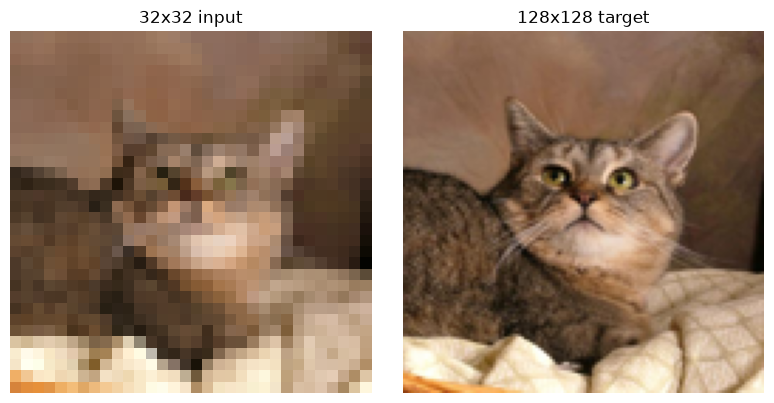

In [7]:
low_resolution, high_resolution = next(iter(train_loader))

def display_image(image):
    image = image.detach().cpu()
    image = (image.clamp(-1, 1) + 1) / 2
    return image.permute(1, 2, 0)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(display_image(low_resolution[0]))
axes[0].set_title('32x32 input')
axes[0].axis('off')

axes[1].imshow(display_image(high_resolution[0]))
axes[1].set_title('128x128 target')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Build the Generator

The generator uses residual blocks and two upsampling steps to create a 128x128 image from a 32x32 input.

In [8]:
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(channels),
            nn.PReLU(),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(channels),
        )

    def forward(self, images):
        return images + self.layers(images)


class Generator(nn.Module):
    def __init__(self, residual_blocks):
        super().__init__()
        self.initial = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=9, padding=4),
            nn.PReLU(),
        )
        self.residuals = nn.Sequential(*[ResidualBlock(64) for _ in range(residual_blocks)])
        self.after_residuals = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
        )
        self.upsample = nn.Sequential(
            nn.Conv2d(64, 256, kernel_size=3, padding=1),
            nn.PixelShuffle(2),
            nn.PReLU(),
            nn.Conv2d(64, 256, kernel_size=3, padding=1),
            nn.PixelShuffle(2),
            nn.PReLU(),
        )
        self.output = nn.Sequential(
            nn.Conv2d(64, 3, kernel_size=9, padding=4),
            nn.Tanh(),
        )

    def forward(self, low_resolution):
        initial_features = self.initial(low_resolution)
        features = self.residuals(initial_features)
        features = self.after_residuals(features) + initial_features
        return self.output(self.upsample(features))

## Build the Discriminator

The discriminator learns to tell real high-resolution images apart from images created by the generator.

In [9]:
class DiscriminatorBlock(nn.Module):
    def __init__(self, input_channels, output_channels, stride):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(input_channels, output_channels, kernel_size=3, stride=stride, padding=1),
            nn.BatchNorm2d(output_channels),
            nn.LeakyReLU(0.2),
        )

    def forward(self, images):
        return self.layers(images)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.LeakyReLU(0.2),
            DiscriminatorBlock(32, 64, stride=2),
            DiscriminatorBlock(64, 128, stride=1),
            DiscriminatorBlock(128, 128, stride=2),
            DiscriminatorBlock(128, 256, stride=1),
            DiscriminatorBlock(256, 256, stride=2),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 1),
        )

    def forward(self, images):
        return self.classifier(self.features(images))

In [10]:
generator = Generator(RESIDUAL_BLOCKS).to(DEVICE)
discriminator = Discriminator().to(DEVICE)

In [11]:
generator_parameters = sum(parameter.numel() for parameter in generator.parameters())
discriminator_parameters = sum(parameter.numel() for parameter in discriminator.parameters())

print(generator)
print('Generator parameters:', generator_parameters)
print('Generator device:', next(generator.parameters()).device)
print()
print(discriminator)
print('Discriminator parameters:', discriminator_parameters)
print('Discriminator device:', next(discriminator.parameters()).device)

Generator(
  (initial): Sequential(
    (0): Conv2d(3, 64, kernel_size=(9, 9), stride=(1, 1), padding=(4, 4))
    (1): PReLU(num_parameters=1)
  )
  (residuals): Sequential(
    (0): ResidualBlock(
      (layers): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): PReLU(num_parameters=1)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (1): ResidualBlock(
      (layers): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): PReLU(num_parameters=1)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(64, eps=1e-05,

## Train SRGAN

Train the generator and discriminator together on CUDA while saving regular checkpoints and showing epoch progress.

In [12]:
def format_duration(seconds):
    seconds = max(0, int(round(seconds)))
    minutes, seconds = divmod(seconds, 60)
    hours, minutes = divmod(minutes, 60)

    if hours > 0:
        return f'{hours}h {minutes}m {seconds}s'
    if minutes > 0:
        return f'{minutes}m {seconds}s'
    return f'{seconds}s'


def update_progress(progress_display, epoch_number, batch_number, total_batches, average_epoch_seconds):
    percent_complete = 100 * batch_number / total_batches

    if average_epoch_seconds is None:
        time_text = 'Avg: calculating... | Est. completion: calculating...'
    else:
        remaining_epochs = EPOCHS - epoch_number + (1 - percent_complete / 100)
        estimated_seconds = average_epoch_seconds * remaining_epochs
        time_text = f'Avg: {format_duration(average_epoch_seconds)} | Est. completion: {format_duration(estimated_seconds)}'

    progress_html = HTML(
        f'''<div style="display: flex; align-items: center; gap: 10px; max-width: 1100px; margin: 8px 0; color: #166534; font-family: sans-serif; font-size: 12px; font-weight: 600; white-space: nowrap;">
        <span>Epoch {epoch_number}/{EPOCHS} | Training</span>
        <div style="flex: 1; min-width: 80px; height: 12px; background: #dcfce7; border: 1px solid #86efac; border-radius: 6px; overflow: hidden;">
            <div style="width: {percent_complete:.0f}%; height: 100%; background: #16a34a;"></div>
        </div>
        <span>{batch_number}/{total_batches} | {percent_complete:.0f}%</span>
        <span>{time_text}</span>
        </div>'''
    )

    if progress_display is None:
        display(progress_html)
    else:
        progress_display.update(progress_html)


def save_checkpoint(epoch_number, history, generator, discriminator, generator_optimizer, discriminator_optimizer):
    checkpoint = {
        'epoch': epoch_number,
        'generator_state_dict': generator.state_dict(),
        'discriminator_state_dict': discriminator.state_dict(),
        'generator_optimizer_state_dict': generator_optimizer.state_dict(),
        'discriminator_optimizer_state_dict': discriminator_optimizer.state_dict(),
        'history': history,
    }
    torch.save(checkpoint, MODELS_DIR / 'last.pt')

    if epoch_number % CHECKPOINT_INTERVAL == 0 or epoch_number == EPOCHS:
        checkpoint_path = MODELS_DIR / f'epoch_{epoch_number:03d}.pt'
        torch.save(checkpoint, checkpoint_path)
        print('Saved checkpoint:', checkpoint_path)

    history_path = OUTPUT_DIR / 'training_history.json'
    history_path.write_text(json.dumps(history, indent=2), encoding='utf-8')

In [13]:
adversarial_loss = nn.BCEWithLogitsLoss()
content_loss = nn.L1Loss()
generator_optimizer = torch.optim.Adam(generator.parameters(), lr=LEARNING_RATE, betas=(0.9, 0.999))
discriminator_optimizer = torch.optim.Adam(discriminator.parameters(), lr=LEARNING_RATE, betas=(0.9, 0.999))

In [14]:
history = []
progress_display = display(HTML(''), display_id=True)

for epoch in range(EPOCHS):
    epoch_number = epoch + 1

    if history:
        average_epoch_seconds = sum(record['epoch_seconds'] for record in history) / len(history)
    else:
        average_epoch_seconds = None

    epoch_start = time.perf_counter()
    generator.train()
    discriminator.train()
    generator_loss_total = 0.0
    discriminator_loss_total = 0.0
    content_loss_total = 0.0
    total_batches = len(train_loader)

    for batch_number, (low_resolution, high_resolution) in enumerate(train_loader, start=1):
        low_resolution = low_resolution.to(DEVICE, non_blocking=True)
        high_resolution = high_resolution.to(DEVICE, non_blocking=True)
        batch_size = low_resolution.size(0)
        real_targets = torch.ones(batch_size, 1, device=DEVICE)
        fake_targets = torch.zeros(batch_size, 1, device=DEVICE)

        discriminator_optimizer.zero_grad()
        generated_images = generator(low_resolution)
        real_loss = adversarial_loss(discriminator(high_resolution), real_targets)
        fake_loss = adversarial_loss(discriminator(generated_images.detach()), fake_targets)
        discriminator_loss = (real_loss + fake_loss) / 2
        discriminator_loss.backward()
        discriminator_optimizer.step()

        generator_optimizer.zero_grad()
        generated_images = generator(low_resolution)
        generator_adversarial_loss = adversarial_loss(discriminator(generated_images), real_targets)
        generator_content_loss = content_loss(generated_images, high_resolution)
        generator_loss = generator_content_loss + ADVERSARIAL_WEIGHT * generator_adversarial_loss
        generator_loss.backward()
        generator_optimizer.step()

        generator_loss_total += generator_loss.item()
        discriminator_loss_total += discriminator_loss.item()
        content_loss_total += generator_content_loss.item()

        if batch_number == 1 or batch_number % PROGRESS_EVERY_BATCHES == 0 or batch_number == total_batches:
            update_progress(progress_display, epoch_number, batch_number, total_batches, average_epoch_seconds)

    epoch_seconds = time.perf_counter() - epoch_start
    epoch_results = {
        'epoch': epoch_number,
        'generator_loss': generator_loss_total / total_batches,
        'discriminator_loss': discriminator_loss_total / total_batches,
        'content_loss': content_loss_total / total_batches,
        'epoch_seconds': epoch_seconds,
    }
    history.append(epoch_results)
    save_checkpoint(
        epoch_number,
        history,
        generator,
        discriminator,
        generator_optimizer,
        discriminator_optimizer,
    )

    average_epoch_seconds = sum(record['epoch_seconds'] for record in history) / len(history)
    estimated_seconds = average_epoch_seconds * (EPOCHS - epoch_number)
    print(
        f'Epoch {epoch_number}/{EPOCHS} complete | '
        f'generator loss: {epoch_results["generator_loss"]:.4f} | '
        f'discriminator loss: {epoch_results["discriminator_loss"]:.4f} | '
        f'content loss: {epoch_results["content_loss"]:.4f} | '
        f'time: {format_duration(epoch_seconds)} | '
        f'avg epoch: {format_duration(average_epoch_seconds)} | '
        f'est. time to completion: {format_duration(estimated_seconds)}',
        flush=True,
    )

c:\Users\Matt Shaver\OneDrive\Desktop\DSBA-6165-Sum-2026-Take-Home-Exam\.venv\Lib\site-packages\PIL\TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 1/150 complete | generator loss: 0.1096 | discriminator loss: 0.1905 | content loss: 0.1074 | time: 1m 25s | avg epoch: 1m 25s | est. time to completion: 3h 30m 35s
Epoch 2/150 complete | generator loss: 0.0860 | discriminator loss: 0.0454 | content loss: 0.0824 | time: 1m 24s | avg epoch: 1m 24s | est. time to completion: 3h 27m 49s
Epoch 3/150 complete | generator loss: 0.0817 | discriminator loss: 0.0345 | content loss: 0.0773 | time: 1m 22s | avg epoch: 1m 23s | est. time to completion: 3h 24m 14s
Epoch 4/150 complete | generator loss: 0.0793 | discriminator loss: 0.0170 | content loss: 0.0746 | time: 1m 22s | avg epoch: 1m 23s | est. time to completion: 3h 21m 56s
Epoch 5/150 complete | generator loss: 0.0777 | discriminator loss: 0.0274 | content loss: 0.0725 | time: 1m 22s | avg epoch: 1m 23s | est. time to completion: 3h 20m 7s
Epoch 6/150 complete | generator loss: 0.0750 | discriminator loss: 0.0537 | content loss: 0.0709 | time: 1m 21s | avg epoch: 1m 22s | est. time t

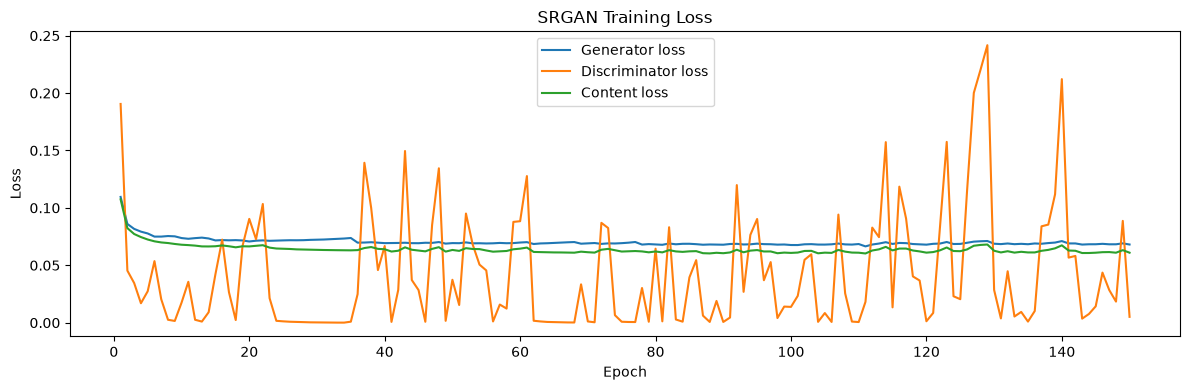

In [15]:
history_table = pd.DataFrame(history)

plt.figure(figsize=(12, 4))
plt.plot(history_table['epoch'], history_table['generator_loss'], label='Generator loss')
plt.plot(history_table['epoch'], history_table['discriminator_loss'], label='Discriminator loss')
plt.plot(history_table['epoch'], history_table['content_loss'], label='Content loss')
plt.title('SRGAN Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_history.png', dpi=200)
plt.show()

## Show Generated Test Images

Compare the low-resolution input, the SRGAN result, and the real high-resolution target for test images.

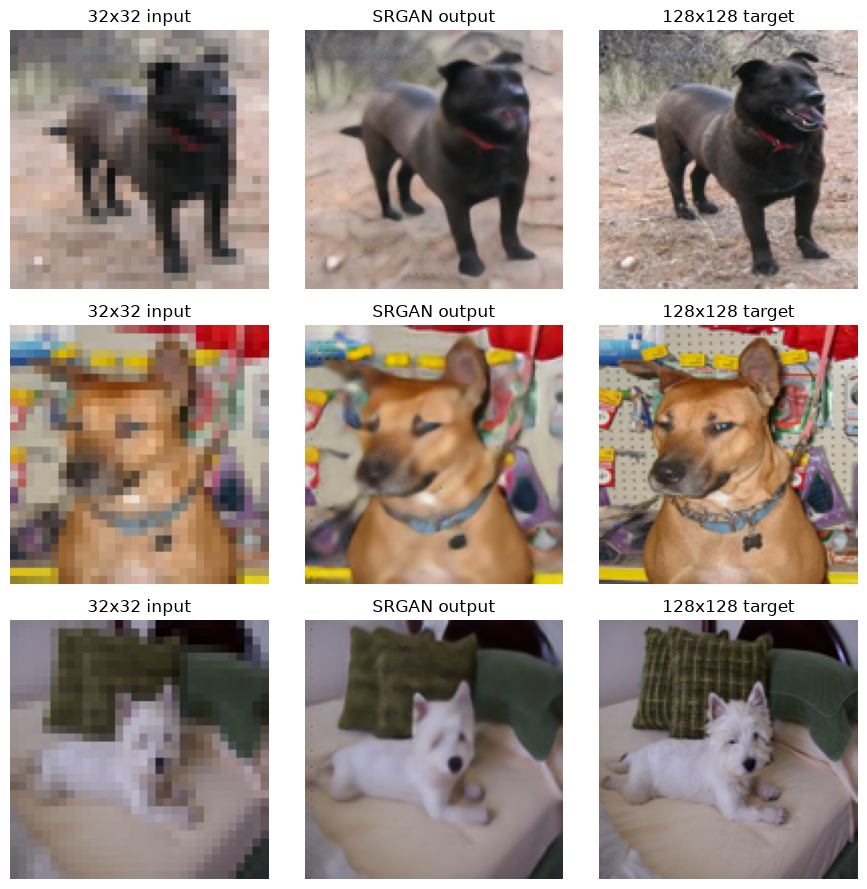

In [16]:
checkpoint_path = MODELS_DIR / 'last.pt'
if not checkpoint_path.exists():
    raise FileNotFoundError('Train SRGAN before generating test images.')

checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
generator.load_state_dict(checkpoint['generator_state_dict'])
generator.eval()

low_resolution, high_resolution = next(iter(test_loader))
with torch.no_grad():
    generated_images = generator(low_resolution.to(DEVICE)).cpu()

fig, axes = plt.subplots(3, 3, figsize=(9, 9))
for row in range(3):
    upscaled_input = low_resolution[row].unsqueeze(0)
    upscaled_input = torch.nn.functional.interpolate(
        upscaled_input,
        size=(HIGH_RESOLUTION_SIZE, HIGH_RESOLUTION_SIZE),
        mode='nearest',
    ).squeeze(0)

    axes[row, 0].imshow(display_image(upscaled_input))
    axes[row, 0].set_title('32x32 input')
    axes[row, 1].imshow(display_image(generated_images[row]))
    axes[row, 1].set_title('SRGAN output')
    axes[row, 2].imshow(display_image(high_resolution[row]))
    axes[row, 2].set_title('128x128 target')

    for column in range(3):
        axes[row, column].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'generated_test_images.png', dpi=200)
plt.show()

## Checkpoints

`last.pt` saves the most recent training state after every epoch. A separate checkpoint is saved every 10 epochs in `models/srgan/`.